# Calculadora de costos Azure


In [1]:
# 0. Configuración inicial

# Instala dependencias mínimas si faltan.

import sys
import subprocess
import importlib.util
from pathlib import Path

paquetes = {
    "requests": "requests",
    "yaml": "pyyaml",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tabulate": "tabulate",
    "fpdf": "fpdf2",
}

faltantes = [
    paquete
    for modulo, paquete in paquetes.items()
    if importlib.util.find_spec(modulo) is None
]

if faltantes:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])

print("Entorno listo.")


Entorno listo.


In [2]:
# 1. Inventario base de recursos

# Este YAML es el BOM editable (respaldo).
# Se usa SOLO si no hay un plan de Terraform cargado (tfplan.json).
# Mantenerlo alineado con terraform/ (region, SKUs, conteos).

COST_INPUTS_YAML = "\n# Inventario de respaldo alineado con terraform/ (Hub-and-Spoke privado).\n# IMPORTANTE:\n# 1) Editable a proposito. Los meters de Azure varian por region / wording del SKU.\n# 2) La ruta autoritativa es tfplan.json -> BOM. Este YAML es el fallback.\n# 3) Precios desde Azure Retail Prices API (retail publico), no de contrato.\n#\n# Cambios clave reflejados desde terraform/:\n#   - Region real: mexicocentral\n#   - Bastion SKU: Standard (no Basic)\n#   - Application Gateway WAF_v2 con capacity = 1 CU\n#   - 6 Private Endpoints (4 spoke1 + 1 spoke2 blob + 1 hub key vault)\n#   - 1 unico App Service Plan B1 Linux (4 web apps lo comparten)\n#   - VMs IaaS: NVA hub-transit (B4s_v2), DNS forwarder (B2ls_v2),\n#     ETL (B2ls_v2), Dashboard (B2ls_v2), Jumpbox Windows (B4s_v2)\n\ndefaults:\n  region: mexicocentral\n  currency: USD\n  meter_region: primary\n  timeout_seconds: 45\n  retries: 3\n  fail_fast: false\n  allow_failures: true\n\nresources:\n  # -------------------------------\n  # NETWORK / SECURITY\n  # -------------------------------\n  - name: vpn_gateway_base\n    notes: \"1 x VPN Gateway P2S (VpnGw1AZ -> VpnGw1), 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'VPN Gateway') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"VpnGw1\"]\n      exclude: [\"Tunnel\", \"Connection\", \"Data Transfer\", \"Inter-virtual\", \"Outbound\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: bastion_standard\n    notes: \"Azure Bastion Standard, 1 host, 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Bastion') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"Standard\"]\n      exclude: [\"Data Transfer\", \"Outbound\", \"Basic\", \"Premium\", \"Additional\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: app_gateway_waf_fixed\n    notes: \"Application Gateway WAF v2 cargo fijo, 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Application Gateway') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"Web Application Firewall\"]\n      exclude: [\"Capacity Unit\", \"Basic Preview\", \"Standard\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: app_gateway_waf_capacity_units\n    notes: \"Application Gateway WAF v2 capacity units; 1 CU * 730 h = 730\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Application Gateway') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"Web Application Firewall\", \"Capacity Unit\"]\n      exclude: [\"Basic Preview\", \"Standard\"]\n      unit_any: [\"Hour\"]\n      min_score: 10\n\n  - name: private_endpoints_base\n    notes: \"6 private endpoints * 730 h = 4380\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Private Link') and priceType eq 'Consumption'\"\n    usage: 4380\n    selector:\n      include: [\"Private Endpoint\"]\n      exclude: [\"Inbound Data\", \"Outbound Data\", \"Private Link Service\"]\n      unit_any: [\"Hour\"]\n      min_score: 10\n\n  - name: private_endpoints_data_processed\n    notes: \"100 GB/mes a traves de Private Endpoints\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Private Link') and priceType eq 'Consumption'\"\n    usage: 100\n    selector:\n      include: [\"Inbound Data\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n\n  # -------------------------------\n  # COMPUTE / IaaS (VMs)\n  # -------------------------------\n  - name: nva_hub_transit_vm\n    notes: \"NVA hub-transit Linux Standard_B4s_v2 (ruteo inter-spoke), 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B4s\"]\n      exclude: [\"Windows\", \"Spot\", \"Low Priority\", \"Dedicated Host\"]\n      unit_any: [\"Hour\"]\n      min_score: 5\n\n  - name: dns_forwarder_vm\n    notes: \"DNS forwarder Linux Standard_B2ls_v2, 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B2ls\"]\n      exclude: [\"Windows\", \"Spot\", \"Low Priority\", \"Dedicated Host\"]\n      unit_any: [\"Hour\"]\n      min_score: 5\n\n  - name: etl_worker_vm\n    notes: \"ETL worker Linux Standard_B2ls_v2 (Spoke 3), 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B2ls\"]\n      exclude: [\"Windows\", \"Spot\", \"Low Priority\", \"Dedicated Host\"]\n      unit_any: [\"Hour\"]\n      min_score: 5\n\n  - name: dashboard_vm\n    notes: \"Dashboard Linux Standard_B2ls_v2 (Spoke 3), 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B2ls\"]\n      exclude: [\"Windows\", \"Spot\", \"Low Priority\", \"Dedicated Host\"]\n      unit_any: [\"Hour\"]\n      min_score: 5\n\n  - name: jumpbox_windows_vm\n    notes: \"Jumpbox Windows Standard_B4s_v2 (Management), 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B4s\", \"Windows\"]\n      exclude: [\"Spot\", \"Low Priority\", \"Dedicated Host\", \"Linux\"]\n      unit_any: [\"Hour\"]\n      min_score: 5\n\n  # -------------------------------\n  # APP PLATFORM\n  # -------------------------------\n  # Azure App Service se cobra por PLAN, no por app.\n  # Las 4 web apps comparten 1 unico App Service Plan B1 Linux.\n  - name: app_service_linux_b1_plan\n    notes: \"App Service Plan unico, B1 Linux, 730 h/mes (4 web apps lo comparten)\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'App Service') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B1\", \"Linux\"]\n      exclude: [\"SSL\", \"Domain\", \"Certificate\", \"JBoss\", \"IP SSL\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: key_vault_secret_operations\n    notes: \"100,000 operaciones de secreto/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Key Vault') and priceType eq 'Consumption'\"\n    usage: 100000\n    selector:\n      include: [\"Secrets\"]\n      exclude: [\"Certificate\", \"Renewal\", \"HSM\", \"Storage account key rotation\"]\n      unit_any: [\"Transaction\", \"Operation\"]\n      min_score: 5\n\n  - name: monitor_log_analytics_ingestion\n    notes: \"20 GB/mes de ingesta de logs\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Monitor') and priceType eq 'Consumption'\"\n    usage: 20\n    selector:\n      include: [\"Ingestion\", \"Logs\"]\n      exclude: [\"Alert\", \"Metric\", \"Notification\", \"Web Test\", \"Retention\", \"Export\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n\n  # -------------------------------\n  # DATA LAYER\n  # -------------------------------\n  - name: mysql_app_compute\n    notes: \"App DB compute B1ms, 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B1ms\"]\n      exclude: [\"Storage\", \"Backup\", \"IOPS\", \"Replica\", \"Accelerated Logs\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: mysql_app_storage\n    notes: \"App DB 64 GB-mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'\"\n    usage: 64\n    selector:\n      include: [\"Storage\"]\n      exclude: [\"Backup\", \"IOPS\", \"Replica\", \"Accelerated Logs\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n\n  - name: mysql_admin_compute\n    notes: \"Admin DB compute B1ms, 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B1ms\"]\n      exclude: [\"Storage\", \"Backup\", \"IOPS\", \"Replica\", \"Accelerated Logs\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: mysql_admin_storage\n    notes: \"Admin DB 64 GB-mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'\"\n    usage: 64\n    selector:\n      include: [\"Storage\"]\n      exclude: [\"Backup\", \"IOPS\", \"Replica\", \"Accelerated Logs\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n\n  - name: mysql_analytics_compute\n    notes: \"Analytics DB compute B1ms, 730 h/mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'\"\n    usage: 730\n    selector:\n      include: [\"B1ms\"]\n      exclude: [\"Storage\", \"Backup\", \"IOPS\", \"Replica\", \"Accelerated Logs\"]\n      unit_any: [\"Hour\", \"Month\"]\n      min_score: 10\n\n  - name: mysql_analytics_storage\n    notes: \"Analytics DB 128 GB-mes\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'\"\n    usage: 128\n    selector:\n      include: [\"Storage\"]\n      exclude: [\"Backup\", \"IOPS\", \"Replica\", \"Accelerated Logs\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n\n  - name: blob_storage_documents_lrs\n    notes: \"100 GB-mes Hot LRS (cuenta documents, Spoke 2)\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Storage') and priceType eq 'Consumption'\"\n    usage: 100\n    selector:\n      include: [\"Hot\"]\n      exclude: [\"Read\", \"Write\", \"Operation\", \"Retrieval\", \"Archive\", \"Cool\", \"Cold\", \"Premium\", \"Geo\", \"GRS\", \"RA-GRS\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n\n  - name: blob_storage_packages_lrs\n    notes: \"50 GB-mes Hot LRS (cuenta packages, Spoke 1)\"\n    filter: \"armRegionName eq '{region}' and contains(serviceName, 'Storage') and priceType eq 'Consumption'\"\n    usage: 50\n    selector:\n      include: [\"Hot\"]\n      exclude: [\"Read\", \"Write\", \"Operation\", \"Retrieval\", \"Archive\", \"Cool\", \"Cold\", \"Premium\", \"Geo\", \"GRS\", \"RA-GRS\"]\n      unit_any: [\"GB\"]\n      min_score: 5\n"

print("Inventario base cargado.")
print(f"Tamaño: {len(COST_INPUTS_YAML)} caracteres")


Inventario base cargado.
Tamaño: 9800 caracteres


# Script: Terraform → BOM → Azure Retail Prices API


In [3]:
# 2. Script: Terraform -> BOM

# Convierte un plan JSON de Terraform en un inventario de costos.

import copy
import json
import re
import yaml
from pathlib import Path
from typing import Any, Dict, List, Optional

TFPLAN_JSON = "tfplan.json"

# Reglas para mapear recursos Terraform a partidas de costo.
# _sku_field : campo en values{} que contiene el SKU del recurso.
# _size_field: campo en values{} que contiene el tamaño (solo VMs).
# Ambos se inyectan dinámicamente en selector.include al convertir.
RESOURCE_PRICING_RULES = {
    "azurerm_bastion_host": {
        "name": "Azure Bastion",
        # filter usa contains para mayor robustez
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Bastion') and priceType eq 'Consumption'",
        "usage": 730,
        "_sku_field": "sku",          # Basic | Standard
        "selector": {
            "include": [],            # SKU inyectado dinámicamente
            "exclude": ["Data Transfer", "Outbound", "Additional"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_virtual_network_gateway": {
        "name": "VPN Gateway",
        "filter": "armRegionName eq '{region}' and serviceName eq 'VPN Gateway' and priceType eq 'Consumption'",
        "usage": 730,
        "_sku_field": "sku",          # VpnGw1AZ → normalizado a VpnGw1
        "selector": {
            "include": [],            # VpnGw1 inyectado dinámicamente
            "exclude": ["Connection", "Data Transfer", "Inter-VNet", "P2S", "S2S", "Tunnel", "Redundancy"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_application_gateway": {
        "name": "Application Gateway",
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Application Gateway') and priceType eq 'Consumption'",
        "usage": 730,
        "_sku_field": "sku",          # list[{name: WAF_v2, tier: WAF_v2}] → "WAF"
        "selector": {
            "include": [],            # "WAF" inyectado si tier es WAF_v2
            "exclude": ["Capacity Unit", "Data Transfer", "Basic"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_service_plan": {
        "name": "App Service Plan",
        "filter": "armRegionName eq '{region}' and serviceName eq 'Azure App Service' and priceType eq 'Consumption'",
        "usage": 730,
        "selector": {
            "include": ["B1"],
            "exclude": ["Free", "Shared", "SSL", "Domain", "Certificate", "JBoss"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_linux_web_app": {
        "name": "Linux Web App",
        "skip_reason": "El costo se cobra en el App Service Plan.",
    },
    "azurerm_windows_web_app": {
        "name": "Windows Web App",
        "skip_reason": "El costo se cobra en el App Service Plan.",
    },
    "azurerm_mysql_flexible_server": {
        "name": "Azure Database for MySQL",
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'MySQL') and priceType eq 'Consumption'",
        "usage": 730,
        "selector": {
            "include": ["B1ms"],
            "exclude": ["Storage", "Backup", "IOPS", "Replica", "Accelerated Logs"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_private_endpoint": {
        "name": "Private Endpoint",
        # CORRECCIÓN: usar contains, no eq — el nombre exacto en la API varía.
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Private Link') and priceType eq 'Consumption'",
        "usage": 730,
        "selector": {
            "include": ["Private Endpoint"],
            "exclude": ["Data Processed", "Inbound Data", "Outbound Data", "Private Link Service"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_key_vault": {
        "name": "Key Vault Operations",
        "filter": "armRegionName eq '{region}' and serviceName eq 'Key Vault' and priceType eq 'Consumption'",
        "usage": 10000,
        "_sku_field": "sku_name",     # standard | premium
        "selector": {
            "include": [],            # "standard" inyectado desde values.sku_name
            "exclude": ["HSM", "Certificate", "Premium", "Renewal", "Rotation"],
            "unit_any": ["Operations", "Transactions"],
            "min_score": 5,
        },
    },
    "azurerm_storage_account": {
        "name": "Storage Account",
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Storage') and priceType eq 'Consumption'",
        "usage": 100,
        "selector": {
            "include": ["Hot", "LRS", "Data Stored"],
            "exclude": ["Write", "Read", "Operations", "Archive", "Cool", "Cold", "Premium", "GRS", "RA-GRS", "ZRS"],
            "unit_any": ["GB"],
            "min_score": 5,
        },
    },
    "azurerm_log_analytics_workspace": {
        "name": "Log Analytics",
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Monitor') and priceType eq 'Consumption'",
        "usage": 10,
        "selector": {
            "include": ["Data Ingestion"],
            "exclude": ["Retention", "Alert", "Metric", "Free Benefit", "Sentinel", "Commitment", "Export", "Basic Logs"],
            "unit_any": ["GB"],
            "min_score": 5,
        },
    },
    # ── VMs ──────────────────────────────────────────────────────────────────
    "azurerm_linux_virtual_machine": {
        "name": "Linux VM",
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'",
        "usage": 730,
        "_size_field": "size",        # Standard_B2ls_v2 → "B2ls"
        "selector": {
            "include": [],            # clave del tamaño inyectada dinámicamente
            "exclude": ["Windows", "Spot", "Low Priority", "Dedicated Host"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
    "azurerm_windows_virtual_machine": {
        "name": "Windows VM",
        "filter": "armRegionName eq '{region}' and contains(serviceName, 'Virtual Machines') and priceType eq 'Consumption'",
        "usage": 730,
        "_size_field": "size",        # Standard_B4s_v2 → "B4s"
        "selector": {
            "include": ["Windows"],   # clave del tamaño inyectada dinámicamente
            "exclude": ["Spot", "Low Priority", "Dedicated Host", "Linux"],
            "unit_any": ["Hour"],
            "min_score": 5,
        },
    },
}


def _sku_to_include_term(resource_type: str, raw: str) -> str:
    """Normaliza el valor de SKU/size de Terraform a un término útil para selector.include."""
    if resource_type == "azurerm_virtual_network_gateway":
        # VpnGw1AZ → VpnGw1
        return re.sub(r"AZ$", "", raw, flags=re.IGNORECASE) or raw
    if resource_type == "azurerm_application_gateway":
        # WAF_v2 → "WAF";  Standard_v2 → "Standard"
        return "WAF" if "WAF" in raw.upper() else raw.split("_")[0]
    if resource_type in ("azurerm_linux_virtual_machine", "azurerm_windows_virtual_machine"):
        # Standard_B2ls_v2 → "B2ls"  (parte central entre guiones bajos)
        m = re.search(r"_([A-Za-z][A-Za-z0-9]+)_", raw)
        return m.group(1) if m else raw
    # Para Bastion (Standard/Basic) y Key Vault (standard): usar tal cual
    return raw


def walk_modules(module: Dict[str, Any]) -> List[Dict[str, Any]]:
    resources = list(module.get("resources", []))
    for child in module.get("child_modules", []):
        resources.extend(walk_modules(child))
    return resources


def load_terraform_resources(tfplan_path: str) -> List[Dict[str, Any]]:
    path = Path(tfplan_path)
    if not path.exists():
        return []
    with open(path, "r", encoding="utf-8") as f:
        plan = json.load(f)
    root = plan.get("planned_values", {}).get("root_module", {})
    return walk_modules(root)


def get_region_from_resource(resource: Dict[str, Any], default_region: str) -> str:
    values = resource.get("values", {}) or {}
    for key in ["location", "region"]:
        if values.get(key):
            return str(values[key]).replace(" ", "").lower()
    return default_region


# mexicocentral no publica precios para la serie Bsv2 (B4s_v2 / B2ls_v2) en el
# Azure Retail Prices API. Tasamos las VMs IaaS con el meter Bsv2 real de East US
# (precio identico en eastus/eastus2/westus2). El resto conserva mexicocentral.
VM_PRICE_REGION = "eastus"
VM_RESOURCE_TYPES = ("azurerm_linux_virtual_machine", "azurerm_windows_virtual_machine")


def _price_region(resource_type: str, region: str) -> str:
    return VM_PRICE_REGION if resource_type in VM_RESOURCE_TYPES else region


def terraform_resource_to_cost_item(resource: Dict[str, Any], default_region: str) -> Optional[Dict[str, Any]]:
    resource_type = resource.get("type")
    rule = RESOURCE_PRICING_RULES.get(resource_type)

    if not rule:
        return None

    if "skip_reason" in rule:
        return {
            "name": rule["name"],
            "terraform_type": resource_type,
            "terraform_name": resource.get("name"),
            "skip": True,
            "skip_reason": rule["skip_reason"],
        }

    values = resource.get("values", {}) or {}
    selector = copy.deepcopy(rule.get("selector", {}))
    extra_vars: Dict[str, Any] = {}

    # Inyección dinámica de SKU (Bastion, VPN GW, App GW, Key Vault)
    sku_field = rule.get("_sku_field")
    if sku_field:
        raw = values.get(sku_field)
        raw_str: Optional[str] = None
        if isinstance(raw, str):
            raw_str = raw
        elif isinstance(raw, list) and raw:
            entry = raw[0]
            if isinstance(entry, dict):
                raw_str = entry.get("name") or entry.get("tier") or ""
            elif isinstance(entry, str):
                raw_str = entry
        if raw_str:
            term = _sku_to_include_term(resource_type, raw_str)
            if term:
                selector.setdefault("include", [])
                if term not in selector["include"]:
                    selector["include"].insert(0, term)
                extra_vars["sku"] = term

    # Inyección dinámica de tamaño de VM
    size_field = rule.get("_size_field")
    if size_field:
        raw_size = values.get(size_field)
        if raw_size:
            term = _sku_to_include_term(resource_type, str(raw_size))
            if term:
                selector.setdefault("include", [])
                if term not in selector["include"]:
                    selector["include"].insert(0, term)
                extra_vars["size"] = term

    item = {
        "name": f"{rule['name']} ({resource.get('name')})",
        "terraform_type": resource_type,
        "terraform_name": resource.get("name"),
        "region": _price_region(resource_type, get_region_from_resource(resource, default_region)),
        "filter": rule["filter"],
        "usage": rule["usage"],
        "selector": selector,
    }
    item.update(extra_vars)
    return item


def build_bom_from_terraform(tfplan_path: str, defaults: Dict[str, Any]) -> Dict[str, Any]:
    resources = load_terraform_resources(tfplan_path)
    bom = {
        "defaults": defaults.copy(),
        "resources": [],
        "skipped": [],
        "unmapped": [],
    }
    for resource in resources:
        item = terraform_resource_to_cost_item(resource, defaults["region"])
        if item is None:
            bom["unmapped"].append({
                "terraform_type": resource.get("type"),
                "terraform_name": resource.get("name"),
            })
            continue
        if item.get("skip"):
            bom["skipped"].append(item)
            continue
        bom["resources"].append(item)
    return bom


def bom_to_estimator_yaml(bom: Dict[str, Any]) -> str:
    estimator_cfg = {
        "defaults": bom["defaults"],
        "resources": bom["resources"],
    }
    return yaml.safe_dump(estimator_cfg, sort_keys=False, allow_unicode=True)


# Región real del despliegue leída del plan de Terraform.
TERRAFORM_DEFAULTS = {
    "region": "mexicocentral",
    "currency": "USD",
    "meter_region": "primary",
    "timeout_seconds": 45,
    "retries": 3,
    "allow_failures": True,
}

terraform_bom = build_bom_from_terraform(TFPLAN_JSON, TERRAFORM_DEFAULTS)

if terraform_bom["resources"]:
    TERRAFORM_COST_INPUTS_YAML = bom_to_estimator_yaml(terraform_bom)
    print("BOM generado desde Terraform.")
    print("Recursos costeables:", len(terraform_bom["resources"]))
    print("Recursos omitidos:", len(terraform_bom["skipped"]))
    print("Recursos sin mapeo:", len(terraform_bom["unmapped"]))
else:
    TERRAFORM_COST_INPUTS_YAML = None
    print("No se encontró tfplan.json o no hubo recursos mapeables.")
    print("Se usará el inventario base del notebook.")


BOM generado desde Terraform.
Recursos costeables: 22
Recursos omitidos: 4
Recursos sin mapeo: 110


In [4]:
#!/usr/bin/env python3
"""
Azure Retail Prices API cost estimator.

What it does
------------
- Reads a YAML file that describes billable line items.
- Queries the official Azure Retail Prices API.
- Uses simple include/exclude selectors to pick the correct meter.
- Converts the API meter/unit into a monthly cost using a usage value you provide.
- Prints a detailed breakdown and can export JSON / CSV.

Why this design?
----------------
Azure pricing is not exposed as a single "upload my Terraform and return total" endpoint.
The Retail Prices API returns prices by meter / SKU / region. This script therefore models
an estimate as billable line items that you can map from Terraform, from a README architecture,
or from a manually curated BOM.

Examples
--------
Estimate from YAML:
    python azure_retail_cost_estimator.py estimate -c repo_cost_inputs.yaml

Estimate and export files:
    python azure_retail_cost_estimator.py estimate -c repo_cost_inputs.yaml \
        --out-json estimate.json --out-csv estimate.csv

Discover likely meters for a search term:
    python azure_retail_cost_estimator.py discover --region eastus --search bastion
    python azure_retail_cost_estimator.py discover --region eastus --search vpn --limit 50

Validate config without calling the API:
    python azure_retail_cost_estimator.py validate -c repo_cost_inputs.yaml
"""

from __future__ import annotations

import argparse
import csv
import json
import math
import os
import re
import sys
import time
from dataclasses import dataclass, field, asdict
from typing import Any, Dict, Iterable, List, Optional, Tuple

import requests
import yaml

API_URL = "https://prices.azure.com/api/retail/prices?api-version=2023-01-01-preview"
DEFAULT_TIMEOUT = 45
DEFAULT_RETRIES = 3
USER_AGENT = "azure-retail-cost-estimator/1.0"


class EstimatorError(Exception):
    pass


@dataclass
class MeterSelection:
    item: Dict[str, Any]
    score: int
    reasons: List[str] = field(default_factory=list)


@dataclass
class LineItemResult:
    name: str
    usage: float
    unit_of_measure: str
    normalized_meter_quantity: float
    unit_price: float
    currency: str
    monthly_cost: float
    selector_score: int
    filter_used: str
    matched_fields: Dict[str, Any]
    debug_reasons: List[str] = field(default_factory=list)


class AzureRetailClient:
    def __init__(self, timeout: int = DEFAULT_TIMEOUT, retries: int = DEFAULT_RETRIES):
        self.timeout = timeout
        self.retries = retries
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": USER_AGENT, "Accept": "application/json"})

    def query(self, filter_query: str, currency: str = "USD", meter_region: Optional[str] = "primary") -> List[Dict[str, Any]]:
        """Query Azure Retail Prices API with pagination."""
        items: List[Dict[str, Any]] = []
        url = API_URL
        params: Optional[Dict[str, str]] = {
            "$filter": filter_query,
            "currencyCode": f"'{currency}'",
        }
        if meter_region:
            params["meterRegion"] = f"'{meter_region}'"

        while url:
            data = self._get_json(url, params=params)
            page_items = data.get("Items", [])
            if not isinstance(page_items, list):
                raise EstimatorError("Unexpected API response shape: 'Items' is not a list")
            items.extend(page_items)
            url = data.get("NextPageLink")
            params = None
        return items

    def _get_json(self, url: str, params: Optional[Dict[str, str]]) -> Dict[str, Any]:
        last_error: Optional[Exception] = None
        for attempt in range(1, self.retries + 1):
            try:
                resp = self.session.get(url, params=params, timeout=self.timeout)
                if resp.status_code >= 400:
                    raise EstimatorError(
                        f"API request failed ({resp.status_code}) for URL {resp.url}\nResponse: {resp.text[:800]}"
                    )
                return resp.json()
            except Exception as exc:
                last_error = exc
                if attempt == self.retries:
                    break
                time.sleep(min(2 ** attempt, 10))
        raise EstimatorError(f"API request failed after {self.retries} attempts: {last_error}")


# Utility helpers

def load_yaml(path: str) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)
    if not isinstance(data, dict):
        raise EstimatorError("YAML root must be a mapping/object")
    return data


def safe_format(text: str, context: Dict[str, Any]) -> str:
    """Format a string with context variables but raise a friendly error if a key is missing."""
    try:
        return text.format(**context)
    except KeyError as e:
        raise EstimatorError(f"Missing placeholder in context for filter/query template: {e}")


def ci_contains(text: Optional[str], needle: str) -> bool:
    return needle.lower() in (text or "").lower()


def parse_quantity_from_unit(unit_of_measure: str) -> float:
    """Extract the denominator from unitOfMeasure.

    Examples:
      '1 Hour' -> 1
      '10000 Transactions' -> 10000
      '10K' -> 10000   (Azure shorthand for Key Vault operations)
      '1 GB/Month' -> 1
      '1 Million' -> 1000000
    """
    if not unit_of_measure:
        return 1.0
    unit = unit_of_measure.strip().replace(",", "")
    # Handle compact suffixes without space: "10K" → 10,000; "1M" → 1,000,000
    m0 = re.match(r"^(\d+(?:\.\d+)?)([KkMm])$", unit)
    if m0:
        qty = float(m0.group(1))
        return qty * (1_000 if m0.group(2).upper() == "K" else 1_000_000)
    m = re.match(r"^(\d+(?:\.\d+)?)\s+([A-Za-z].*)$", unit)
    if m:
        qty = float(m.group(1))
        tail = m.group(2).lower()
        if "million" in tail:
            return qty * 1_000_000
        if "thousand" in tail:
            return qty * 1_000
        return qty
    m2 = re.search(r"(\d+(?:\.\d+)?)", unit)
    if m2:
        return float(m2.group(1))
    return 1.0


def money(v: float) -> str:
    return f"{v:,.4f}"


def render_item_summary(item: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "serviceName": item.get("serviceName"),
        "productName": item.get("productName"),
        "skuName": item.get("skuName"),
        "armSkuName": item.get("armSkuName"),
        "meterName": item.get("meterName"),
        "unitOfMeasure": item.get("unitOfMeasure"),
        "retailPrice": item.get("retailPrice"),
        "currencyCode": item.get("currencyCode"),
        "armRegionName": item.get("armRegionName"),
        "type": item.get("type") or item.get("priceType"),
    }


def dedupe_items(items: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    seen = set()
    out = []
    for item in items:
        key = (
            item.get("serviceName"),
            item.get("productName"),
            item.get("skuName"),
            item.get("armSkuName"),
            item.get("meterName"),
            item.get("unitOfMeasure"),
            item.get("retailPrice"),
            item.get("armRegionName"),
        )
        if key not in seen:
            seen.add(key)
            out.append(item)
    return out


# Selector / scoring logic

def score_item(item: Dict[str, Any], selector: Dict[str, Any]) -> MeterSelection:
    include_terms = [str(x) for x in selector.get("include", [])]
    exclude_terms = [str(x) for x in selector.get("exclude", [])]
    preferred_units = [str(x) for x in selector.get("unit_any", [])]
    prefer_primary = bool(selector.get("prefer_primary_region", True))
    exact = selector.get("exact", {}) or {}

    searchable_fields = {
        "serviceName": item.get("serviceName") or "",
        "productName": item.get("productName") or "",
        "skuName": item.get("skuName") or "",
        "armSkuName": item.get("armSkuName") or "",
        "meterName": item.get("meterName") or "",
        "unitOfMeasure": item.get("unitOfMeasure") or "",
        "type": item.get("type") or item.get("priceType") or "",
    }

    score = 0
    reasons: List[str] = []

    # Exact field matches
    for field_name, expected in exact.items():
        actual = str(searchable_fields.get(field_name, ""))
        if actual.lower() == str(expected).lower():
            score += 120
            reasons.append(f"exact:{field_name}={expected}")
        else:
            score -= 120
            reasons.append(f"miss-exact:{field_name}!={expected}")

    # Include terms
    for term in include_terms:
        term_hit = False
        for field_name, text in searchable_fields.items():
            if ci_contains(text, term):
                term_hit = True
                # prioritize certain fields more than others
                weight = {
                    "skuName": 60,
                    "armSkuName": 60,
                    "meterName": 50,
                    "productName": 35,
                    "serviceName": 25,
                    "unitOfMeasure": 10,
                    "type": 5,
                }.get(field_name, 10)
                score += weight
                reasons.append(f"include:{term}@{field_name}")
                break
        if not term_hit:
            score -= 50
            reasons.append(f"miss-include:{term}")

    # Exclude terms
    for term in exclude_terms:
        for field_name, text in searchable_fields.items():
            if ci_contains(text, term):
                score -= 200
                reasons.append(f"exclude:{term}@{field_name}")
                break

    # Preferred units
    if preferred_units:
        unit_text = searchable_fields["unitOfMeasure"]
        if any(ci_contains(unit_text, u) for u in preferred_units):
            score += 35
            reasons.append("preferred-unit")
        else:
            score -= 35
            reasons.append("not-preferred-unit")

    # Favor primary region meters when available
    if prefer_primary:
        if item.get("isPrimaryMeterRegion") is True:
            score += 10
            reasons.append("primary-meter-region")
        elif item.get("isPrimaryMeterRegion") is False:
            score -= 10
            reasons.append("non-primary-meter-region")

    # Prefer Consumption over DevTest / Reservation for estimation unless explicitly selected
    item_type = str(searchable_fields.get("type", ""))
    if item_type.lower() == "consumption":
        score += 10
        reasons.append("consumption")
    elif item_type.lower() == "reservation":
        score -= 15
        reasons.append("reservation")
    elif item_type:
        score -= 5
        reasons.append(f"type:{item_type}")

    # Tiny preference for lower price among otherwise similar matches is applied later.
    return MeterSelection(item=item, score=score, reasons=reasons)


def choose_best_item(items: List[Dict[str, Any]], selector: Dict[str, Any], allow_zero_results: bool = False) -> MeterSelection:
    if not items:
        if allow_zero_results:
            return MeterSelection(item={}, score=-9999, reasons=["no-items"])
        raise EstimatorError("No API items returned for this filter")

    scored = [score_item(item, selector) for item in items]
    # sort by score desc, price asc, meterName asc for deterministic output
    scored.sort(
        key=lambda x: (
            -x.score,
            float(x.item.get("retailPrice") if x.item.get("retailPrice") is not None else math.inf),
            str(x.item.get("meterName") or ""),
        )
    )
    best = scored[0]
    if best.score < selector.get("min_score", -9999):
        top_previews = [render_item_summary(x.item) for x in scored[:10]]
        raise EstimatorError(
            "No candidate meter met the selector requirements.\n"
            f"Best score: {best.score}\n"
            f"Top candidates: {json.dumps(top_previews, indent=2)}"
        )
    return best


# -----------------------------
# Estimation engine
# -----------------------------

def validate_config(cfg: Dict[str, Any]) -> None:
    if "defaults" not in cfg:
        raise EstimatorError("Config must contain a 'defaults' section")
    if "resources" not in cfg:
        raise EstimatorError("Config must contain a 'resources' list")
    if not isinstance(cfg["resources"], list) or not cfg["resources"]:
        raise EstimatorError("'resources' must be a non-empty list")

    defaults = cfg["defaults"]
    if "region" not in defaults:
        raise EstimatorError("defaults.region is required")
    if "currency" not in defaults:
        raise EstimatorError("defaults.currency is required")

    for idx, resource in enumerate(cfg["resources"], start=1):
        if not isinstance(resource, dict):
            raise EstimatorError(f"resources[{idx}] must be an object/mapping")
        for req in ["name", "filter", "usage"]:
            if req not in resource:
                raise EstimatorError(f"resources[{idx}] missing required field: {req}")
        selector = resource.get("selector", {})
        if selector is not None and not isinstance(selector, dict):
            raise EstimatorError(f"resources[{idx}].selector must be an object")


def build_context(defaults: Dict[str, Any], resource: Dict[str, Any]) -> Dict[str, Any]:
    ctx = {}
    ctx.update(defaults)
    # flattened custom vars at top-level resource for convenience
    for k, v in resource.items():
        if k not in {"selector", "debug", "notes"}:
            ctx[k] = v
    # support nested vars as well
    vars_map = resource.get("vars", {})
    if isinstance(vars_map, dict):
        ctx.update(vars_map)
    return ctx


def estimate_from_config(cfg: Dict[str, Any], debug: bool = False) -> Dict[str, Any]:
    validate_config(cfg)
    defaults = cfg["defaults"]
    client = AzureRetailClient(
        timeout=int(defaults.get("timeout_seconds", DEFAULT_TIMEOUT)),
        retries=int(defaults.get("retries", DEFAULT_RETRIES)),
    )
    region = str(defaults["region"])
    currency = str(defaults["currency"])
    meter_region = defaults.get("meter_region", "primary")

    results: List[LineItemResult] = []
    failures: List[Dict[str, Any]] = []

    for resource in cfg["resources"]:
        name = str(resource["name"])
        try:
            ctx = build_context(defaults, resource)
            ctx.setdefault("region", region)
            ctx.setdefault("currency", currency)
            filter_query = safe_format(str(resource["filter"]), ctx)
            usage = float(resource["usage"])
            selector = resource.get("selector", {}) or {}

            items = client.query(filter_query=filter_query, currency=currency, meter_region=meter_region)
            items = dedupe_items(items)
            best = choose_best_item(items, selector)
            unit_of_measure = str(best.item.get("unitOfMeasure") or "")
            price = float(best.item.get("retailPrice"))
            normalized_qty = parse_quantity_from_unit(unit_of_measure)
            if normalized_qty == 0:
                raise EstimatorError(f"Parsed zero quantity from unitOfMeasure='{unit_of_measure}'")
            monthly_cost = price * (usage / normalized_qty)

            result = LineItemResult(
                name=name,
                usage=usage,
                unit_of_measure=unit_of_measure,
                normalized_meter_quantity=normalized_qty,
                unit_price=price,
                currency=str(best.item.get("currencyCode") or currency),
                monthly_cost=monthly_cost,
                selector_score=best.score,
                filter_used=filter_query,
                matched_fields=render_item_summary(best.item),
                debug_reasons=best.reasons if (debug or resource.get("debug") is True) else [],
            )
            results.append(result)
        except Exception as exc:
            failures.append({"name": name, "error": str(exc)})
            if defaults.get("fail_fast", False):
                raise

    total_monthly = sum(r.monthly_cost for r in results)
    total_annual = total_monthly * 12
    return {
        "metadata": {
            "region": region,
            "currency": currency,
            "meter_region": meter_region,
            "results_count": len(results),
            "failures_count": len(failures),
        },
        "line_items": [asdict(r) for r in results],
        "failures": failures,
        "summary": {
            "monthly_total": total_monthly,
            "annual_total": total_annual,
            "currency": currency,
        },
    }


def discover(region: str, search: str, currency: str = "USD", limit: int = 25, service_name: Optional[str] = None) -> List[Dict[str, Any]]:
    client = AzureRetailClient()
    if service_name:
        filter_query = f"armRegionName eq '{region}' and serviceName eq '{service_name}' and priceType eq 'Consumption'"
    else:
        # Use a moderate filter to keep result size practical.
        # Search term is applied server-side to multiple likely fields.
        term = search.replace("'", "''")
        filter_query = (
            f"armRegionName eq '{region}' and priceType eq 'Consumption' and ("
            f"contains(serviceName, '{term}') or contains(productName, '{term}') or "
            f"contains(skuName, '{term}') or contains(armSkuName, '{term}') or contains(meterName, '{term}'))"
        )
    items = client.query(filter_query=filter_query, currency=currency, meter_region="primary")
    items = dedupe_items(items)
    # client-side relevance ranking
    ranked = []
    for item in items:
        score = 0
        for field in ["serviceName", "productName", "skuName", "armSkuName", "meterName"]:
            text = str(item.get(field) or "")
            if text.lower() == search.lower():
                score += 100
            elif search.lower() in text.lower():
                score += 20
        if item.get("isPrimaryMeterRegion") is True:
            score += 5
        if str(item.get("type") or item.get("priceType") or "").lower() == "consumption":
            score += 2
        ranked.append((score, item))
    ranked.sort(key=lambda x: (-x[0], float(x[1].get("retailPrice") or math.inf), str(x[1].get("meterName") or "")))
    return [render_item_summary(item) for _, item in ranked[:limit]]


# -----------------------------
# Output helpers
# -----------------------------

def print_estimate(result: Dict[str, Any]) -> None:
    md = result["metadata"]
    summary = result["summary"]
    line_items = result["line_items"]
    failures = result["failures"]

    print("=" * 100)
    print("AZURE RETAIL PRICE ESTIMATE")
    print("=" * 100)
    print(f"Region     : {md['region']}")
    print(f"Currency   : {summary['currency']}")
    print(f"Line items : {md['results_count']}")
    print(f"Failures   : {md['failures_count']}")
    print("-" * 100)

    for li in line_items:
        print(f"NAME             : {li['name']}")
        print(f"MONTHLY COST     : {li['currency']} {money(li['monthly_cost'])}")
        print(f"USAGE            : {li['usage']} (API unit: {li['unit_of_measure']}; normalized qty: {li['normalized_meter_quantity']})")
        print(f"UNIT PRICE       : {li['currency']} {money(li['unit_price'])}")
        mf = li["matched_fields"]
        print(f"MATCHED SERVICE  : {mf.get('serviceName')}")
        print(f"MATCHED PRODUCT  : {mf.get('productName')}")
        print(f"MATCHED SKU      : {mf.get('skuName')} | ARM SKU: {mf.get('armSkuName')}")
        print(f"MATCHED METER    : {mf.get('meterName')}")
        print(f"SELECTOR SCORE   : {li['selector_score']}")
        print(f"FILTER           : {li['filter_used']}")
        if li.get("debug_reasons"):
            print(f"DEBUG REASONS    : {', '.join(li['debug_reasons'])}")
        print("-" * 100)

    print(f"MONTHLY TOTAL    : {summary['currency']} {money(summary['monthly_total'])}")
    print(f"ANNUAL TOTAL     : {summary['currency']} {money(summary['annual_total'])}")

    if failures:
        print("\nFAILURES")
        print("-" * 100)
        for f in failures:
            print(f"- {f['name']}: {f['error']}")


def write_json(path: str, payload: Dict[str, Any]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


def write_csv(path: str, payload: Dict[str, Any]) -> None:
    rows = payload.get("line_items", [])
    if not rows:
        with open(path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["name", "monthly_cost", "currency"])
        return
    headers = [
        "name",
        "monthly_cost",
        "currency",
        "usage",
        "unit_of_measure",
        "normalized_meter_quantity",
        "unit_price",
        "selector_score",
        "filter_used",
        "serviceName",
        "productName",
        "skuName",
        "armSkuName",
        "meterName",
        "armRegionName",
        "type",
    ]
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=headers)
        writer.writeheader()
        for li in rows:
            mf = li.get("matched_fields", {})
            writer.writerow(
                {
                    "name": li.get("name"),
                    "monthly_cost": li.get("monthly_cost"),
                    "currency": li.get("currency"),
                    "usage": li.get("usage"),
                    "unit_of_measure": li.get("unit_of_measure"),
                    "normalized_meter_quantity": li.get("normalized_meter_quantity"),
                    "unit_price": li.get("unit_price"),
                    "selector_score": li.get("selector_score"),
                    "filter_used": li.get("filter_used"),
                    "serviceName": mf.get("serviceName"),
                    "productName": mf.get("productName"),
                    "skuName": mf.get("skuName"),
                    "armSkuName": mf.get("armSkuName"),
                    "meterName": mf.get("meterName"),
                    "armRegionName": mf.get("armRegionName"),
                    "type": mf.get("type"),
                }
            )


# 2. Notebook helper functions

# These helpers wrap the estimator logic so the notebook can
# validate, estimate, inspect, plot and export results without
# depending on any external .py or .yaml file.

import io
import os
import copy
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display


def load_yaml_from_string(yaml_string: str) -> Dict[str, Any]:
    # Load the embedded YAML inventory.
    data = yaml.safe_load(io.StringIO(yaml_string))
    if not isinstance(data, dict):
        raise EstimatorError("YAML root must be a mapping/object.")
    return data


def estimate_from_yaml_string(yaml_string: str, debug: bool = False) -> Dict[str, Any]:
    # Run the full Azure Retail Prices API estimation from embedded YAML.
    cfg = load_yaml_from_string(yaml_string)
    return estimate_from_config(cfg, debug=debug)


def line_items_dataframe(payload: Dict[str, Any]) -> pd.DataFrame:
    # Flatten successful line-item results into a clean DataFrame.
    rows = []

    for li in payload.get("line_items", []):
        mf = li.get("matched_fields", {})

        rows.append({
            "resource": li.get("name"),
            "monthly_cost": li.get("monthly_cost"),
            "annual_cost": li.get("monthly_cost", 0) * 12,
            "currency": li.get("currency"),
            "usage": li.get("usage"),
            "api_unit": li.get("unit_of_measure"),
            "normalized_qty": li.get("normalized_meter_quantity"),
            "unit_price": li.get("unit_price"),
            "service": mf.get("serviceName"),
            "product": mf.get("productName"),
            "sku": mf.get("skuName"),
            "arm_sku": mf.get("armSkuName"),
            "meter": mf.get("meterName"),
            "region": mf.get("armRegionName"),
            "price_type": mf.get("type"),
            "selector_score": li.get("selector_score"),
            "filter_used": li.get("filter_used"),
        })

    return pd.DataFrame(rows)


def failures_dataframe(payload: Dict[str, Any]) -> pd.DataFrame:
    # Return failed resources, useful for tuning selectors.
    return pd.DataFrame(payload.get("failures", []))


def summary_dataframe(payload: Dict[str, Any]) -> pd.DataFrame:
    # Create a one-row summary table.
    metadata = payload.get("metadata", {})
    summary = payload.get("summary", {})

    return pd.DataFrame([{
        "region": metadata.get("region"),
        "currency": summary.get("currency"),
        "estimated_resources": metadata.get("results_count"),
        "failed_resources": metadata.get("failures_count"),
        "monthly_total": summary.get("monthly_total"),
        "annual_total": summary.get("annual_total"),
    }])


def add_cost_share(df: pd.DataFrame) -> pd.DataFrame:
    # Add percentage contribution of each resource to total monthly cost.
    if df.empty:
        return df

    out = df.copy()
    total = out["monthly_cost"].sum()

    if total > 0:
        out["monthly_share_pct"] = (out["monthly_cost"] / total) * 100
    else:
        out["monthly_share_pct"] = 0.0

    return out.sort_values("monthly_cost", ascending=False)


def export_cost_outputs(payload: Dict[str, Any], output_dir: str = "outputs") -> Dict[str, str]:
    # Export JSON, CSV and compact Markdown summary.
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    json_file = output_path / "azure_cost_estimate.json"
    csv_file = output_path / "azure_cost_estimate.csv"
    md_file = output_path / "azure_cost_summary.md"

    write_json(str(json_file), payload)
    write_csv(str(csv_file), payload)

    summary_df = summary_dataframe(payload)
    detail_df = add_cost_share(line_items_dataframe(payload))

    with open(md_file, "w", encoding="utf-8") as f:
        f.write("# Azure Cost Estimate Summary\n\n")

        if not summary_df.empty:
            row = summary_df.iloc[0]
            f.write(f"- Region: `{row['region']}`\n")
            f.write(f"- Currency: `{row['currency']}`\n")
            f.write(f"- Estimated resources: `{row['estimated_resources']}`\n")
            f.write(f"- Failed resources: `{row['failed_resources']}`\n")
            f.write(f"- Monthly total: **{row['currency']} {row['monthly_total']:,.4f}**\n")
            f.write(f"- Annual total: **{row['currency']} {row['annual_total']:,.4f}**\n\n")

        if not detail_df.empty:
            cols = ["resource", "monthly_cost", "annual_cost", "monthly_share_pct", "currency"]
            f.write(detail_df[cols].to_markdown(index=False))

    return {
        "json": str(json_file),
        "csv": str(csv_file),
        "markdown": str(md_file),
    }


def plot_monthly_costs(df: pd.DataFrame) -> None:
    # Plot estimated monthly cost by resource.
    if df.empty:
        print("No successful line items to plot.")
        return

    plot_df = df.sort_values("monthly_cost", ascending=True)

    plt.figure(figsize=(10, max(5, len(plot_df) * 0.35)))
    plt.barh(plot_df["resource"], plot_df["monthly_cost"])
    plt.xlabel("Estimated monthly cost")
    plt.ylabel("Resource")
    plt.title("Estimated monthly Azure cost by resource")
    plt.tight_layout()
    plt.show()


def discover_meters(search: str, region: Optional[str] = None, currency: Optional[str] = None, limit: int = 25) -> pd.DataFrame:
    # Discover candidate meters to tune YAML selectors.
    cfg = load_yaml_from_string(ACTIVE_COST_INPUTS_YAML if 'ACTIVE_COST_INPUTS_YAML' in globals() else COST_INPUTS_YAML)
    defaults = cfg["defaults"]

    rows = discover(
        region=region or defaults["region"],
        search=search,
        currency=currency or defaults["currency"],
        limit=limit,
    )

    return pd.DataFrame(rows)


def run_sensitivity_scenario(usage_factor: float) -> Tuple[Dict[str, Any], pd.DataFrame]:
    # Re-estimate after multiplying all uso mensual.
    scenario_cfg = copy.deepcopy(load_yaml_from_string(ACTIVE_COST_INPUTS_YAML if 'ACTIVE_COST_INPUTS_YAML' in globals() else COST_INPUTS_YAML))

    for resource in scenario_cfg["resources"]:
        if "usage" in resource:
            resource["usage"] = float(resource["usage"]) * usage_factor

    scenario_yaml = yaml.safe_dump(
        scenario_cfg,
        sort_keys=False,
        allow_unicode=True,
    )

    scenario_payload = estimate_from_yaml_string(scenario_yaml, debug=False)
    return scenario_payload, summary_dataframe(scenario_payload)


In [5]:
# 3. Validar inventario

# Si existe BOM desde Terraform, se usa ese.
# Si no, se usa el YAML base del notebook.

ACTIVE_COST_INPUTS_YAML = (
    TERRAFORM_COST_INPUTS_YAML
    if "TERRAFORM_COST_INPUTS_YAML" in globals() and TERRAFORM_COST_INPUTS_YAML
    else COST_INPUTS_YAML
)

cfg = load_yaml_from_string(ACTIVE_COST_INPUTS_YAML)
validate_config(cfg)

print("Configuración válida.")
print("Fuente:", "Terraform" if ACTIVE_COST_INPUTS_YAML != COST_INPUTS_YAML else "Inventario base")
print("Región:", cfg["defaults"]["region"])
print("Moneda:", cfg["defaults"]["currency"])
print("Recursos:", len(cfg["resources"]))

if "terraform_bom" in globals() and terraform_bom.get("unmapped"):
    print("Recursos Terraform sin mapeo:", len(terraform_bom["unmapped"]))


Configuración válida.
Fuente: Terraform
Región: mexicocentral
Moneda: USD
Recursos: 22
Recursos Terraform sin mapeo: 110


In [6]:
# 3.1 Revisión del mapeo Terraform

import pandas as pd
from IPython.display import display

if "terraform_bom" in globals() and terraform_bom["resources"]:
    print("Recursos costeables desde Terraform:")
    display(pd.DataFrame(terraform_bom["resources"])[[
        "name", "terraform_type", "terraform_name", "usage"
    ]])

    if terraform_bom["skipped"]:
        print("Recursos omitidos:")
        display(pd.DataFrame(terraform_bom["skipped"]))

    if terraform_bom["unmapped"]:
        print("Recursos sin mapeo:")
        display(pd.DataFrame(terraform_bom["unmapped"]))
else:
    print("No hay BOM generado desde Terraform.")


Recursos costeables desde Terraform:


,name,terraform_type,terraform_name,usage
0,Application Gateway (main),azurerm_application_gateway,main,730
1,Azure Bastion (main),azurerm_bastion_host,main,730
2,Key Vault Operations (main),azurerm_key_vault,main,10000
3,Linux VM (dns),azurerm_linux_virtual_machine,dns,730
4,Linux VM (nva),azurerm_linux_virtual_machine,nva,730
5,Log Analytics (main),azurerm_log_analytics_workspace,main,10
6,Private Endpoint (key_vault),azurerm_private_endpoint,key_vault,730
7,VPN Gateway (vpn),azurerm_virtual_network_gateway,vpn,730
8,Windows VM (jumpbox),azurerm_windows_virtual_machine,jumpbox,730
9,Private Endpoint (admin),azurerm_private_endpoint,admin,730


Recursos omitidos:


,name,terraform_type,terraform_name,skip,skip_reason
0,Linux Web App,azurerm_linux_web_app,admin,True,El costo se cobra en el App Service Plan.
1,Linux Web App,azurerm_linux_web_app,admin_api,True,El costo se cobra en el App Service Plan.
2,Linux Web App,azurerm_linux_web_app,api,True,El costo se cobra en el App Service Plan.
3,Linux Web App,azurerm_linux_web_app,webapp,True,El costo se cobra en el App Service Plan.


Recursos sin mapeo:


,terraform_type,terraform_name
0,azurerm_key_vault_secret,jumpbox_password
1,azurerm_key_vault_secret,mysql_password
2,azurerm_key_vault_secret,storage_key
3,azurerm_resource_group,main
4,local_file,diagnostics_script
...,...,...
105,azurerm_subnet_route_table_association,dashboard
106,azurerm_subnet_route_table_association,etl
107,azurerm_virtual_network,spoke
108,azurerm_virtual_network_peering,hub_to_spoke


In [7]:
# 4. Buscar meters


search_term = "bastion"

try:
    meters_df = discover_meters(search_term, limit=20)
    display(meters_df)
except Exception as exc:
    print("Falló la búsqueda de meters.")
    print("Motivo:", exc)
    print("Revisar internet, término o región.")


""


In [8]:
# 5. Calcular costos

# Celda principal.
#
# Si falla:
# - revisar failures_df
# - usar búsqueda de meters
# - ajustar selectores

try:
    estimate_payload = estimate_from_yaml_string(ACTIVE_COST_INPUTS_YAML, debug=True)

    summary_df = summary_dataframe(estimate_payload)
    details_df = add_cost_share(line_items_dataframe(estimate_payload))
    failures_df = failures_dataframe(estimate_payload)

    display(summary_df)
    display(details_df)

    if not failures_df.empty:
        print("Algunos recursos fallaron. Ajusta selectores o supuestos.")
        display(failures_df)
    else:
        print("Todos los recursos fueron estimados.")

except Exception as exc:
    estimate_payload = None
    summary_df = pd.DataFrame()
    details_df = pd.DataFrame()
    failures_df = pd.DataFrame()

    print("Falló el cálculo de costos.")
    print("Motivo:", exc)
    print("Revisar internet, región, moneda o selectores.")


,region,currency,estimated_resources,failed_resources,monthly_total,annual_total
0,mexicocentral,USD,16,6,858.491,10301.892


,resource,monthly_cost,annual_cost,currency,usage,api_unit,normalized_qty,unit_price,service,product,sku,arm_sku,meter,region,price_type,selector_score,filter_used,monthly_share_pct
1,Azure Bastion (main),211.700,2540.400,USD,730.0,1 Hour,1.0,0.29000,Azure Bastion,Azure Bastion,Standard,,Standard Gateway,mexicocentral,Consumption,95,armRegionName eq 'mexicocentral' and contains(...,24.659548
6,VPN Gateway (vpn),138.700,1664.400,USD,730.0,1 Hour,1.0,0.19000,VPN Gateway,VPN Gateway,VpnGw1,,VpnGw1,mexicocentral,Consumption,95,armRegionName eq 'mexicocentral' and serviceNa...,16.156256
7,Windows VM (jumpbox),135.050,1620.600,USD,730.0,1 Hour,1.0,0.18500,Virtual Machines,Virtual Machines Bsv2 Series Windows,B4s v2,Standard_B4s_v2,B4s v2,eastus,Consumption,150,armRegionName eq 'eastus' and contains(service...,15.731091
4,Linux VM (nva),121.180,1454.160,USD,730.0,1 Hour,1.0,0.16600,Virtual Machines,Virtual Machines Bsv2 Series,B4s v2,Standard_B4s_v2,B4s v2,eastus,Consumption,115,armRegionName eq 'eastus' and contains(service...,14.115465
0,Application Gateway (main),101.178,1214.136,USD,730.0,1 Hour,1.0,0.13860,Application Gateway,WAF Application Gateway,Medium,,Medium Gateway,mexicocentral,Consumption,90,armRegionName eq 'mexicocentral' and contains(...,11.785563
3,Linux VM (dns),30.368,364.416,USD,730.0,1 Hour,1.0,0.04160,Virtual Machines,Virtual Machines Bsv2 Series,B2ls v2,Standard_B2ls_v2,B2ls v2,eastus,Consumption,115,armRegionName eq 'eastus' and contains(service...,3.537370
13,Linux VM (dashboard),30.368,364.416,USD,730.0,1 Hour,1.0,0.04160,Virtual Machines,Virtual Machines Bsv2 Series,B2ls v2,Standard_B2ls_v2,B2ls v2,eastus,Consumption,115,armRegionName eq 'eastus' and contains(service...,3.537370
14,Linux VM (etl),30.368,364.416,USD,730.0,1 Hour,1.0,0.04160,Virtual Machines,Virtual Machines Bsv2 Series,B2ls v2,Standard_B2ls_v2,B2ls v2,eastus,Consumption,115,armRegionName eq 'eastus' and contains(service...,3.537370
15,Azure Database for MySQL (analytics),13.651,163.812,USD,730.0,1 Hour,1.0,0.01870,Azure Database for MySQL,Azure Database for MySQL Flexible Server Burst...,B1MS,B1MS,B1MS,mexicocentral,Consumption,115,armRegionName eq 'mexicocentral' and contains(...,1.590116
11,Azure Database for MySQL (app),13.651,163.812,USD,730.0,1 Hour,1.0,0.01870,Azure Database for MySQL,Azure Database for MySQL Flexible Server Burst...,B1MS,B1MS,B1MS,mexicocentral,Consumption,115,armRegionName eq 'mexicocentral' and contains(...,1.590116


Algunos recursos fallaron. Ajusta selectores o supuestos.


,name,error
0,Private Endpoint (key_vault),No API items returned for this filter
1,Private Endpoint (admin),No API items returned for this filter
2,Private Endpoint (admin_api),No API items returned for this filter
3,Private Endpoint (api),No API items returned for this filter
4,Private Endpoint (webapp),No API items returned for this filter
5,Private Endpoint (blob),No API items returned for this filter


In [9]:
# 6. Diagnóstico de costos

# Identifica los costos principales.

if "details_df" in globals() and not details_df.empty:
    cost_view = details_df[[
        "resource",
        "monthly_cost",
        "annual_cost",
        "monthly_share_pct",
        "currency",
        "service",
        "sku",
        "meter",
    ]].sort_values("monthly_cost", ascending=False)

    display(cost_view)

    top = cost_view.iloc[0]
    print("Principal costo:")
    print(f"- {top['resource']}: {top['currency']} {top['monthly_cost']:,.4f}/month")
else:
    print("No hay datos estimados.")


,resource,monthly_cost,annual_cost,monthly_share_pct,currency,service,sku,meter
1,Azure Bastion (main),211.700,2540.400,24.659548,USD,Azure Bastion,Standard,Standard Gateway
6,VPN Gateway (vpn),138.700,1664.400,16.156256,USD,VPN Gateway,VpnGw1,VpnGw1
7,Windows VM (jumpbox),135.050,1620.600,15.731091,USD,Virtual Machines,B4s v2,B4s v2
4,Linux VM (nva),121.180,1454.160,14.115465,USD,Virtual Machines,B4s v2,B4s v2
0,Application Gateway (main),101.178,1214.136,11.785563,USD,Application Gateway,Medium,Medium Gateway
3,Linux VM (dns),30.368,364.416,3.537370,USD,Virtual Machines,B2ls v2,B2ls v2
13,Linux VM (dashboard),30.368,364.416,3.537370,USD,Virtual Machines,B2ls v2,B2ls v2
14,Linux VM (etl),30.368,364.416,3.537370,USD,Virtual Machines,B2ls v2,B2ls v2
15,Azure Database for MySQL (analytics),13.651,163.812,1.590116,USD,Azure Database for MySQL,B1MS,B1MS
11,Azure Database for MySQL (app),13.651,163.812,1.590116,USD,Azure Database for MySQL,B1MS,B1MS


Principal costo:
- Azure Bastion (main): USD 211.7000/month


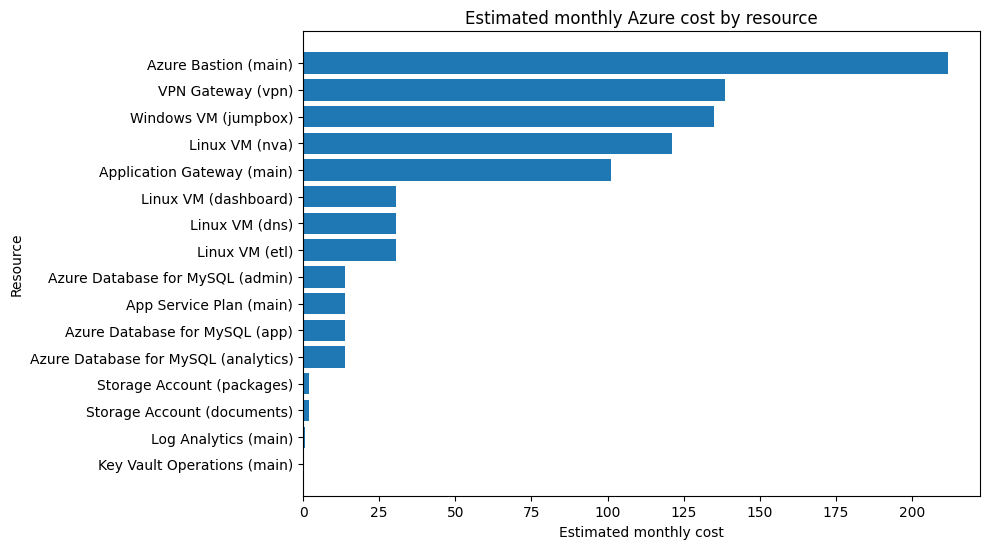

In [10]:
# 7. Graficar costos

if "details_df" in globals() and not details_df.empty:
    plot_monthly_costs(details_df)
else:
    print("No hay datos para graficar.")


In [11]:
# 8. Exportar resultados

if "estimate_payload" in globals() and estimate_payload is not None:
    exported_files = export_cost_outputs(estimate_payload, output_dir="outputs")
    exported_files
else:
    print("Primero ejecuta la celda de cálculo.")


In [12]:
# 9. Escenario de sensibilidad

usage_factor = 1.25

try:
    scenario_payload, scenario_summary_df = run_sensitivity_scenario(usage_factor)
    display(scenario_summary_df)

    if "summary_df" in globals() and not summary_df.empty:
        base_monthly = summary_df["monthly_total"].iloc[0]
        scenario_monthly = scenario_summary_df["monthly_total"].iloc[0]
        currency = scenario_summary_df["currency"].iloc[0]

        print(f"Usage factor: {usage_factor}")
        print(f"Base monthly total: {currency} {base_monthly:,.4f}")
        print(f"Scenario monthly total: {currency} {scenario_monthly:,.4f}")
        print(f"Monthly delta: {currency} {scenario_monthly - base_monthly:,.4f}")

except Exception as exc:
    print("Falló el escenario de sensibilidad.")
    print("Motivo:", exc)


,region,currency,estimated_resources,failed_resources,monthly_total,annual_total
0,mexicocentral,USD,16,6,1073.11375,12877.365


Usage factor: 1.25
Base monthly total: USD 858.4910
Scenario monthly total: USD 1,073.1137
Monthly delta: USD 214.6227


In [13]:
# 10. Generar reporte PDF

from fpdf import FPDF
from fpdf.enums import XPos, YPos
from datetime import datetime
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io


def generate_pdf_report(payload, output_dir="outputs", filename="azure_cost_report.pdf"):
    if payload is None:
        print("No hay datos. Ejecuta primero la celda de cálculo.")
        return None

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    pdf_file = output_path / filename

    metadata = payload.get("metadata", {})
    summary = payload.get("summary", {})
    line_items = payload.get("line_items", [])
    failures = payload.get("failures", [])

    region = metadata.get("region", "N/A")
    currency = summary.get("currency", "USD")
    monthly_total = summary.get("monthly_total", 0)
    annual_total = summary.get("annual_total", 0)
    generated_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line_items_sorted = sorted(line_items, key=lambda x: x.get("monthly_cost", 0), reverse=True)

    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=18)
    pdf.add_page()

    # ── Header ──────────────────────────────────────────────────────────────
    pdf.set_fill_color(37, 99, 235)
    pdf.rect(0, 0, 210, 42, "F")
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 22)
    pdf.set_xy(10, 8)
    pdf.cell(190, 12, "Reporte de Costos Azure", align="C")
    pdf.set_font("Helvetica", "", 11)
    pdf.set_xy(10, 22)
    pdf.cell(190, 8, "Northwind Distribucion - Estimacion con Azure Retail Prices API", align="C")
    pdf.set_font("Helvetica", "", 9)
    pdf.set_xy(10, 33)
    pdf.cell(190, 6, f"Generado: {generated_at}  |  Region: {region}  |  Moneda: {currency}", align="C")

    # ── Summary cards ────────────────────────────────────────────────────────
    pdf.set_text_color(0, 0, 0)
    pdf.set_xy(10, 52)
    pdf.set_font("Helvetica", "B", 13)
    pdf.cell(190, 8, "Resumen Ejecutivo", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.set_draw_color(37, 99, 235)
    pdf.set_line_width(0.5)
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.ln(3)

    def summary_card(x, y, label, value, rgb=(37, 99, 235)):
        pdf.set_fill_color(*rgb)
        pdf.rect(x, y, 58, 24, "F")
        pdf.set_text_color(255, 255, 255)
        pdf.set_font("Helvetica", "", 9)
        pdf.set_xy(x + 2, y + 4)
        pdf.cell(54, 6, label)
        pdf.set_font("Helvetica", "B", 13)
        pdf.set_xy(x + 2, y + 12)
        pdf.cell(54, 8, value)
        pdf.set_text_color(0, 0, 0)

    yc = pdf.get_y()
    summary_card(10,  yc, "Costo Mensual",        f"{currency} {monthly_total:,.2f}")
    summary_card(74,  yc, "Costo Anual",           f"{currency} {annual_total:,.2f}",        rgb=(5, 150, 105))
    summary_card(138, yc, "Recursos Estimados",    str(metadata.get("results_count", 0)),    rgb=(124, 58, 237))
    pdf.set_xy(10, yc + 30)

    # ── Line-items table ─────────────────────────────────────────────────────
    pdf.set_font("Helvetica", "B", 13)
    pdf.cell(190, 8, "Desglose por Recurso", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.set_draw_color(37, 99, 235)
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.ln(3)

    col_w = [68, 32, 32, 22, 36]
    headers = ["Recurso", f"Mensual ({currency})", f"Anual ({currency})", "% Total", "Servicio Azure"]

    pdf.set_fill_color(37, 99, 235)
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 8)
    for h, w in zip(headers, col_w):
        pdf.cell(w, 8, h, border=1, fill=True, align="C")
    pdf.ln()

    pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", "", 8)
    total_m = sum(li.get("monthly_cost", 0) for li in line_items_sorted)
    for i, li in enumerate(line_items_sorted):
        m = li.get("monthly_cost", 0)
        pct = (m / total_m * 100) if total_m > 0 else 0
        svc = (li.get("matched_fields", {}).get("serviceName") or "")[:20]
        fill = i % 2 == 0
        if fill:
            pdf.set_fill_color(241, 245, 249)
        pdf.cell(col_w[0], 7, li.get("name", "")[:35],    border=1, fill=fill)
        pdf.cell(col_w[1], 7, f"{m:,.4f}",                border=1, fill=fill, align="R")
        pdf.cell(col_w[2], 7, f"{m*12:,.4f}",             border=1, fill=fill, align="R")
        pdf.cell(col_w[3], 7, f"{pct:.1f}%",              border=1, fill=fill, align="C")
        pdf.cell(col_w[4], 7, svc,                         border=1, fill=fill)
        pdf.ln()

    pdf.set_fill_color(37, 99, 235)
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 8)
    pdf.cell(col_w[0], 8, "TOTAL",                          border=1, fill=True)
    pdf.cell(col_w[1], 8, f"{monthly_total:,.4f}",          border=1, fill=True, align="R")
    pdf.cell(col_w[2], 8, f"{annual_total:,.4f}",           border=1, fill=True, align="R")
    pdf.cell(col_w[3], 8, "100%",                           border=1, fill=True, align="C")
    pdf.cell(col_w[4], 8, "",                               border=1, fill=True)
    pdf.ln(12)

    # ── Bar chart ────────────────────────────────────────────────────────────
    if line_items_sorted:
        if pdf.get_y() > 160:
            pdf.add_page()

        pdf.set_text_color(0, 0, 0)
        pdf.set_font("Helvetica", "B", 13)
        pdf.cell(190, 8, "Distribucion de Costos Mensuales", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.set_draw_color(37, 99, 235)
        pdf.line(10, pdf.get_y(), 200, pdf.get_y())
        pdf.ln(5)

        names = [li.get("name", "")[:28] for li in reversed(line_items_sorted)]
        costs = [li.get("monthly_cost", 0) for li in reversed(line_items_sorted)]

        fig, ax = plt.subplots(figsize=(9, max(4, len(names) * 0.45)))
        bars = ax.barh(names, costs, color="#2563eb", edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, fmt=lambda v: f"{currency} {v:,.2f}", padding=4, fontsize=8)
        ax.set_xlabel(f"Costo mensual ({currency})", fontsize=10)
        ax.set_title("Estimacion de costos mensuales por recurso", fontsize=12, pad=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="y", labelsize=8)
        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        chart_tmp = output_path / "_chart_tmp.png"
        chart_tmp.write_bytes(buf.read())
        pdf.image(str(chart_tmp), x=10, w=185)
        chart_tmp.unlink(missing_ok=True)
        pdf.ln(5)

    # ── Failures ─────────────────────────────────────────────────────────────
    if failures:
        if pdf.get_y() > 220:
            pdf.add_page()
        pdf.set_text_color(0, 0, 0)
        pdf.set_font("Helvetica", "B", 13)
        pdf.cell(190, 8, "Recursos con Error", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.set_draw_color(220, 38, 38)
        pdf.line(10, pdf.get_y(), 200, pdf.get_y())
        pdf.ln(3)
        pdf.set_font("Helvetica", "", 8)
        for f in failures:
            pdf.set_fill_color(254, 242, 242)
            pdf.set_text_color(220, 38, 38)
            pdf.cell(40, 6, f.get("name", ""), border=1, fill=True)
            pdf.set_text_color(100, 0, 0)
            pdf.cell(150, 6, f.get("error", "")[:120], border=1, fill=True)
            pdf.ln()

    # ── Footer ────────────────────────────────────────────────────────────────
    pdf.set_y(-20)
    pdf.set_draw_color(200, 200, 200)
    pdf.line(10, pdf.get_y(), 200, pdf.get_y())
    pdf.set_font("Helvetica", "I", 8)
    pdf.set_text_color(150, 150, 150)
    pdf.cell(190, 8, f"Northwind Distribucion | Azure Hub-Spoke Intranet | {generated_at}", align="C")

    pdf.output(str(pdf_file))
    print(f"Reporte PDF generado: {pdf_file}")
    return str(pdf_file)


if "estimate_payload" in globals() and estimate_payload is not None:
    pdf_path = generate_pdf_report(estimate_payload, output_dir="outputs")
else:
    print("Primero ejecuta la celda de calculo (celda 5).")


Reporte PDF generado: outputs/azure_cost_report.pdf


In [14]:
# 11. Actualizar sección de costos en el documento técnico

import re
from pathlib import Path

TEX_PATH = Path("docs/documento_tecnico.tex")


def _escape_tex(text: str) -> str:
    """Escape LaTeX special characters in a plain-text string."""
    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"),
        ("%", r"\%"),
        ("$", r"\$"),
        ("#", r"\#"),
        ("_", r"\_"),
        ("{", r"\{"),
        ("}", r"\}"),
        ("~", r"\textasciitilde{}"),
        ("^", r"\textasciicircum{}"),
    ]
    for old, new in replacements:
        text = text.replace(old, new)
    return text


def _build_payg_table(payload: dict) -> str:
    """Build the full LaTeX tabular block for section 11 (PAYG table)."""
    line_items = payload.get("line_items", [])
    sorted_items = sorted(line_items, key=lambda x: x.get("monthly_cost", 0), reverse=True)
    total_monthly = sum(li.get("monthly_cost", 0) for li in sorted_items)
    total_annual = total_monthly * 12
    currency = payload.get("summary", {}).get("currency", "USD")

    rows = []
    for i, li in enumerate(sorted_items):
        m = li.get("monthly_cost", 0)
        a = m * 12
        pct = (m / total_monthly * 100) if total_monthly > 0 else 0
        mf = li.get("matched_fields", {})
        sku = (mf.get("armSkuName") or mf.get("skuName") or "---")
        # Escape & truncate
        name = _escape_tex(li.get("name", ""))[:42]
        sku_tex = _escape_tex(sku)[:22]
        prefix = "  \\rowcolor{tablerow}\n  " if i % 2 == 0 else "  "
        rows.append(
            f"{prefix}{name} & {sku_tex} & {m:>9,.2f} & {a:>10,.2f} & {pct:>5.1f}\\% \\\\"
        )

    rows_str = "\n".join(rows)

    return (
        f"\\begin{{center}}\n"
        f"\\begin{{tabular}}{{>{{\\footnotesize}}p{{5.2cm}}\n"
        f"                >{{\\footnotesize\\ttfamily}}p{{3.2cm}}\n"
        f"                r r r}}\n"
        f"  \\toprule\n"
        f"  \\rowcolor{{tableheader}}\n"
        f"  \\color{{white}}\\bfseries\\normalsize Recurso &\n"
        f"  \\color{{white}}\\bfseries SKU &\n"
        f"  \\color{{white}}\\bfseries Mens. ({currency}) &\n"
        f"  \\color{{white}}\\bfseries Anual ({currency}) &\n"
        f"  \\color{{white}}\\bfseries \\% \\\\\n"
        f"  \\midrule\n"
        f"{rows_str}\n"
        f"  \\midrule\n"
        f"  \\rowcolor{{azuredark}}\n"
        f"  \\multicolumn{{2}}{{l}}{{\\color{{white}}\\bfseries TOTAL MENSUAL (PAYG)}} &\n"
        f"  \\color{{white}}\\bfseries {total_monthly:,.2f} &\n"
        f"  \\color{{white}}\\bfseries {total_annual:,.2f} &\n"
        f"  \\color{{white}}\\bfseries 100\\% \\\\\n"
        f"  \\bottomrule\n"
        f"\\end{{tabular}}\n"
        f"\\end{{center}}"
    )


def _build_payg_note(payload: dict) -> str:
    """Build the italic note summarising the top-3 cost drivers."""
    line_items = payload.get("line_items", [])
    sorted_items = sorted(line_items, key=lambda x: x.get("monthly_cost", 0), reverse=True)
    total_m = sum(li.get("monthly_cost", 0) for li in sorted_items)
    top3 = sorted_items[:3]
    top3_cost = sum(li.get("monthly_cost", 0) for li in top3)
    top3_pct = int(round(top3_cost / total_m * 100)) if total_m > 0 else 0
    names = " + ".join(_escape_tex(li["name"]) for li in top3)
    return (
        f"\\noindent\n"
        f"\\textit{{Los tres servicios más costosos ({names}) concentran\n"
        f"el \\textbf{{{top3_pct}\\%}} del costo mensual.}}"
    )


def update_tex_costs(payload: dict, tex_path: Path = TEX_PATH) -> bool:
    """Replace the cost table and note between markers in the .tex file."""
    if not tex_path.exists():
        print(f"Archivo no encontrado: {tex_path}")
        return False

    source = tex_path.read_text(encoding="utf-8")
    missing = [m for m in ("<<PAYG_TABLE_START>>", "<<PAYG_TABLE_END>>",
                            "<<PAYG_NOTE_START>>",  "<<PAYG_NOTE_END>>")
               if m not in source]
    if missing:
        print(f"Marcadores faltantes en el .tex: {missing}")
        return False

    table_block = _build_payg_table(payload)
    note_block  = _build_payg_note(payload)

    source = re.sub(
        r"% <<PAYG_TABLE_START>>.*?% <<PAYG_TABLE_END>>",
        lambda m: f"% <<PAYG_TABLE_START>>\n{table_block}\n% <<PAYG_TABLE_END>>",
        source, flags=re.DOTALL,
    )
    source = re.sub(
        r"% <<PAYG_NOTE_START>>.*?% <<PAYG_NOTE_END>>",
        lambda m: f"% <<PAYG_NOTE_START>>\n{note_block}\n% <<PAYG_NOTE_END>>",
        source, flags=re.DOTALL,
    )

    tex_path.write_text(source, encoding="utf-8")

    items = payload.get("line_items", [])
    total_m = sum(li.get("monthly_cost", 0) for li in items)
    currency = payload.get("summary", {}).get("currency", "USD")
    print(f"Documento técnico actualizado: {tex_path}")
    print(f"  Recursos costeados : {len(items)}")
    print(f"  Total mensual      : {currency} {total_m:,.2f}")
    print(f"  Total anual        : {currency} {total_m * 12:,.2f}")
    return True


if "estimate_payload" in globals() and estimate_payload is not None:
    update_tex_costs(estimate_payload)
else:
    print("Primero ejecuta la celda de cálculo (celda 5).")


Documento técnico actualizado: docs/documento_tecnico.tex
  Recursos costeados : 16
  Total mensual      : USD 858.49
  Total anual        : USD 10,301.89
